<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/SP500_Sector_Stages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta
!pip install scipy==1.16.2

In [3]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
import time
import ta
import requests
from datetime import datetime, timedelta
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries Installed!")

0.2.66
Libraries Installed!


# Establish Sector Correlation

In [34]:
sector_tickers = {
    "Tech": "XLK",
    "Energy": "XLE",
    "Financials": "XLF",
    "Industrials": "XLI",
    "Consumer_Discretionary": "XLY",
    "Consumer_Staples": "XLP",
    "Healthcare": "XLV",
    "Communications": "XLC",
    "Materials": "XLB",
    "Real_Estate": "XLRE",
    "Utilities": "XLU"
}

data = yf.download(list(sector_tickers.values()), period="1mo", interval="1d", auto_adjust=True)["Close"]

# Drop any days with missing data
data = data.dropna()

# Compute returns
returns = data.pct_change().dropna()

# Compute correlation matrix
corr_matrix = returns.corr()

# Compute average correlation across sectors
corr_values = corr_matrix.values
avg_corr = (np.sum(corr_values) - np.sum(np.diag(corr_values))) / (corr_values.size - len(corr_matrix))
avg_corr

# Interpret whether leadership is REAL
if avg_corr < 0.40:
    leadership = "STRONG leadership – low correlations → Great environment for LONGS"
elif avg_corr < 0.70:
    leadership = "Mixed leadership – correlations moderate → Selective longs only"
else:
    leadership = "Macro-driven market – HIGH correlations → Low follow-through, avoid aggressive longs"


# 7. Print results
corr_matrix



[*********************100%***********************]  11 of 11 completed


Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Ticker,,,,,,,,,,,
XLB,1.000000,0.545551,0.394640,0.847032,0.680237,0.419424,0.565781,0.639066,0.315440,0.694571,0.693357
XLC,0.545551,1.000000,0.161627,0.539275,0.643611,0.553916,0.169906,0.628796,0.265272,0.476219,0.732328
XLE,0.394640,0.161627,1.000000,0.271080,0.207204,0.156097,0.401564,0.459609,0.097424,0.019170,0.205151
XLF,0.847032,0.539275,0.271080,1.000000,0.824517,0.529067,0.382054,0.592377,0.306325,0.543629,0.717940
XLI,0.680237,0.643611,0.207204,0.824517,1.000000,0.679300,0.182345,0.642493,0.423675,0.458017,0.760975
XLK,0.419424,0.553916,0.156097,0.529067,0.679300,1.000000,-0.302011,0.194690,0.256660,0.046575,0.733957
XLP,0.565781,0.169906,0.401564,0.382054,0.182345,-0.302011,1.000000,0.675730,0.215231,0.455508,0.197211
XLRE,0.639066,0.628796,0.459609,0.592377,0.642493,0.194690,0.675730,1.000000,0.590173,0.551763,0.541726
XLU,0.315440,0.265272,0.097424,0.306325,0.423675,0.256660,0.215231,0.590173,1.000000,0.262870,0.266897


In [35]:
print("\nAverage Correlation:", round(avg_corr, 3))


Average Correlation: 0.435


In [36]:
print("\nLeadership Assessment:", leadership)


Leadership Assessment: Mixed leadership – correlations moderate → Selective longs only


In [37]:
returns.tail()

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,
2025-12-01,-0.002461,-0.004680,0.009619,-0.008251,-0.014640,0.000454,-0.001008,-0.013919,-0.023392,-0.014970,0.000592
2025-12-02,-0.009083,0.003309,-0.012922,-0.000945,0.008716,0.010302,-0.006558,-0.002434,-0.007118,-0.005989,-0.000676
2025-12-03,0.007016,-0.000868,0.018749,0.013437,0.009492,0.002385,0.000762,0.001952,-0.003186,0.004664,0.010785
2025-12-04,-0.005843,0.005733,0.004247,0.002054,0.005188,0.003724,-0.004821,-0.001704,-0.002055,-0.007609,-0.003557
2025-12-05,-0.003278,0.011573,-0.004121,0.000373,-0.002774,0.007318,0.000127,-0.000244,-0.009380,-0.004159,0.005543


## Determine Bull or Bear Regime

In [38]:
# 1. Fetch Weekly Price Data
# ---------------------
def get_weekly(ticker, period="2y"):
    data = yf.download(ticker, period=period, interval="1wk", auto_adjust=True)
    data.dropna(inplace=True)
    return data

spy = get_weekly("SPY")
tlt = get_weekly("TLT")
vix = get_weekly("^VIX")

# ---------------------
# 2. Compute Key Indicators
# ---------------------

# 40-week SMA (≈ 200-day SMA)
spy["SMA30"] = spy["Close"].rolling(30).mean()

# Slope of SMA = current SMA - SMA 3 weeks ago
spy["SMA30_slope"] = spy["SMA30"] - spy["SMA30"].shift(3)

# VIX rising or falling trend
vix["VIX_trend_4W"] = vix["Close"] - vix["Close"].shift(4)

# TLT trend vs 30-week SMA
tlt["SMA30"] = tlt["Close"].rolling(30).mean()
tlt["SMA30_slope"] = tlt["SMA30"] - tlt["SMA30"].shift(3)

# ---------------------
# 3. % of S&P500 stocks above 200-day SMA
# ---------------------
pct_above_200 = 53
print(f"\n% of Stocks Above 200-day SMA: {pct_above_200:.1f}%")
pct_above_50 = 39
print(f"\n% of Stocks Above 50-day SMA: {pct_above_50:.1f}%")
stage2_pct = 45
print(f"\n% of Stocks in Stage 2: {stage2_pct:.1f}%")

# ---------------------
# 4. Define Regime Logic
# ---------------------
def determine_regime():

    latest = spy.iloc[-1]
    latest_vix = vix.iloc[-1]
    tlt_latest = tlt.iloc[-1]

    bullish_conditions = [
        latest["Close"].iloc[0] > latest["SMA30"].iloc[0],   # Price > 30-week SMA
        latest["SMA30_slope"].iloc[0] > 0,                   # SMA trending up
        avg_corr    < 0.5   ,                                # Leading sectors outperform strongly
        pct_above_200 > 50,                                  # Breadth positive
        pct_above_50 > 55,                                   # Short-term breadth
        stage2_pct > 55,                                     # Stage 2 leadership
        latest_vix["Close"].iloc[0] < 20 ,                   # Low volatility
        tlt_latest["Close"].iloc[0] > tlt_latest["SMA30"].iloc[0],          # TLT stable/risk-on
        tlt_latest["SMA30_slope"].iloc[0] >= 0                      # TLT not collapsing
    ]

    bearish_conditions = [
        latest["Close"].iloc[0] < latest["SMA30"].iloc[0],         # Price below 30-week SMA
        latest["SMA30_slope"].iloc[0] < 0,                         # Downtrend
        avg_corr   > 0.5   ,                                       # Leading sectors outperform strongly
        pct_above_200 < 45,
        pct_above_50 < 40,
        stage2_pct < 40,
        latest_vix["Close"].iloc[0] > 22  ,                        # Rising volatility
        tlt_latest["Close"] .iloc[0]< tlt_latest["SMA30"].iloc[0],         # Safety bid
        tlt_latest["SMA30_slope"].iloc[0] < 0
    ]

    if sum(bullish_conditions) >= 6:
        return "BULL REGIME"

    if sum(bearish_conditions) >= 6:
        return "BEAR REGIME"

    return "NEUTRAL / TRANSITION"

# ---------------------
# 5. Output regime
# ---------------------
print("Market Regime:", determine_regime())



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


% of Stocks Above 200-day SMA: 53.0%

% of Stocks Above 50-day SMA: 39.0%

% of Stocks in Stage 2: 45.0%
Market Regime: BULL REGIME


## Search for sector to  invest in

In [39]:

# ETF universe
etfs = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB","XLC"]

# Benchmark
benchmark = yf.download("SPY", period="3y", interval="1wk", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


# Classify Sector Stages

In [40]:

def weinstein_stage(df, sma_window1=10, sma_window=30,smaSlope_window=5):
    """Determine Weinstein stage using 30-week SMA and its slope."""
     # Handle MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df["SMA"] = df["Close"].rolling(window=sma_window).mean()
    df["10_SMA"] = df["Close"].rolling(window=sma_window1).mean()

    # Compute linear regression slope on last N SMA points
    if len(df.dropna()) < sma_window:
        return None  # not enough data

    slope, _, _, _, _ = linregress(range(smaSlope_window), df["SMA"].tail(smaSlope_window))
    slope_short, _, _, _, _ = linregress(range(smaSlope_window), df["10_SMA"].tail(smaSlope_window))

    latest_price = df["Close"].iloc[-1]
    latest_sma = df["SMA"].iloc[-1]
    latest_10sma = df["10_SMA"].iloc[-1]
    # (latest_price > latest_sma) and (slope > 0)
    # (latest_price > latest_sma) and (slope > 0) and (slope_short > 0) and (latest_price > latest_10sma) and (latest_10sma > latest_sma)
    # Determine stage
    if (latest_price > latest_sma) and (slope > 0) :
        stage = "Stage 2 (Advancing)"
    elif latest_price < latest_sma and slope < 0:
        stage = "Stage 4 (Declining)"
    elif  np.abs(slope) <= 0.001:
        stage = "Stage 1 (Basing)"
    else:
        stage = "Stage 3 (Topping)"

    return stage, slope, latest_price, latest_sma, latest_10sma,slope_short


In [41]:

results = []
for etf in etfs:
    df = yf.download(etf, period="3y", interval="1wk", auto_adjust=True)
    stage_info = weinstein_stage(df)
    if stage_info:
        stage, slope, price, sma,sma_10, sma_short = stage_info
        results.append({
            "ETF": etf,
            "Stage": stage,
            "SMA_Slope": slope,
            "Latest_Price": price,
            "30W_SMA": sma,
            "10W_SMA": sma_10,
            "10W_SMA_Slope": sma_short
        })

stages_df = pd.DataFrame(results).sort_values(by="SMA_Slope", ascending=False)
advancing_sectors = stages_df[stages_df["Stage"] .isin(["Stage 2 (Advancing)"]) ]
declining_sectors = stages_df[stages_df["Stage"] .isin(["Stage 4 (Declining)","Stage 3 (Topping)","Stage 1 (Basing)"]) ]

# Advancing sectors
advancing_sectors.reset_index(drop=True, inplace=True)

advancing_sectors

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,ETF,Stage,SMA_Slope,Latest_Price,30W_SMA,10W_SMA,10W_SMA_Slope
0,XLK,Stage 2 (Advancing),1.251591,146.600006,132.736929,143.565501,0.558339
1,XLI,Stage 2 (Advancing),0.729747,154.580002,149.619556,152.925000,0.082786
2,XLC,Stage 2 (Advancing),0.647549,117.129997,109.955866,114.235001,-0.331229
3,XLV,Stage 2 (Advancing),0.645200,153.259995,138.710418,148.397000,1.802105
4,XLY,Stage 2 (Advancing),0.602536,119.730003,113.488609,117.339500,-0.294563
5,XLU,Stage 2 (Advancing),0.179753,43.299999,42.517553,44.750000,0.204231
6,XLE,Stage 2 (Advancing),0.166458,45.919998,43.420498,44.479000,0.124006
7,XLF,Stage 2 (Advancing),0.147172,53.680000,52.284217,52.745000,-0.089847


In [42]:
## Sectors to Short
declining_sectors.reset_index(drop=True, inplace=True)
declining_sectors

,ETF,Stage,SMA_Slope,Latest_Price,30W_SMA,10W_SMA,10W_SMA_Slope
0,XLB,Stage 3 (Topping),0.086698,44.090000,44.186507,43.789500,-0.138430
1,XLRE,Stage 3 (Topping),0.022894,40.990002,41.369620,41.413001,-0.059432
2,XLP,Stage 4 (Declining),-0.061570,78.459999,79.618333,78.093000,-0.080798


In [43]:

def compute_mansfield_rs(asset_df, benchmark_df, window):
    """Compute Mansfield Relative Strength (MRS) vs a benchmark."""
    # Handle MultiIndex columns
    if isinstance(asset_df.columns, pd.MultiIndex):
        asset_df.columns = asset_df.columns.get_level_values(0)
    if isinstance(benchmark_df.columns, pd.MultiIndex):
        benchmark_df.columns = benchmark_df.columns.get_level_values(0)

    # Align and clean data
    data = pd.DataFrame({
        "Asset": asset_df["Close"],
        "Benchmark": benchmark_df["Close"]
    }).reindex(asset_df.index.union(benchmark_df.index)).ffill().dropna()

    if len(data) < window:
        return None  # not enough data

    data["RS"] = data["Asset"] / data["Benchmark"]
    data["RS_MA"] = data["RS"].rolling(window=window, min_periods=window).mean()
    data["MRS"] = ((data["RS"] / data["RS_MA"]) - 1) * 100

    return data["MRS"].iloc[-1]  # latest MRS value


In [13]:
# ---------- STAGE 1: 3-MONTH MRS (12 weeks) ----------
advancing_etfs = advancing_sectors["ETF"].tolist()
mrs_3m = {}
for etf in advancing_etfs:
    data = yf.download(etf, period="3y", interval="1wk", auto_adjust=True)
    mrs_value = compute_mansfield_rs(data, benchmark, window=12)
    if mrs_value is not None:
        mrs_3m[etf] = mrs_value

mrs_3m_df = pd.DataFrame(list(mrs_3m.items()), columns=["ETF", "MRS_3M"])

mrs_3m_df


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,ETF,MRS_3M
0,XLK,-0.198115
1,XLY,-1.011219
2,XLI,-0.729862
3,XLV,2.955499
4,XLC,-1.297174
5,XLU,-3.720942
6,XLE,1.337016
7,XLB,-1.504784
8,XLF,-0.780400


In [14]:
mrs_3m_df = mrs_3m_df[mrs_3m_df["MRS_3M"] > 0].sort_values(by="MRS_3M", ascending=False)
print("\n✅ 3-Month Positive MRS ETFs:")
mrs_3m_df.reset_index(drop=True)
mrs_3m_df


✅ 3-Month Positive MRS ETFs:


,ETF,MRS_3M
3,XLV,2.955499
6,XLE,1.337016


In [18]:
# ---------- STAGE 2: 1-MONTH MRS (4 weeks) ----------
selected_etfs = mrs_3m_df["ETF"].tolist()
mrs_1m = {}
for etf in selected_etfs:
    data = yf.download(etf, period="3y", interval="1wk",auto_adjust=True)
    mrs_value = compute_mansfield_rs(data, benchmark, window=4)
    if mrs_value is not None:
        mrs_1m[etf] = mrs_value

mrs_1m_df = pd.DataFrame(list(mrs_1m.items()), columns=["ETF", "MRS_1M"]).sort_values(by="MRS_1M", ascending=False)
#mrs_1m_df = mrs_1m_df[mrs_1m_df["MRS_1M"] > 0].sort_values(by="MRS_1M", ascending=False)
print("\n🔥 1-Month MRS Ranking Among 3M Positive ETFs:")
mrs_1m_df.reset_index(drop=True)
mrs_1m_df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


🔥 1-Month MRS Ranking Among 3M Positive ETFs:


,ETF,MRS_1M
1,XLE,-0.137979
0,XLV,-1.815942


In [19]:

def get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66, period="3mo", interval="1d"):
    """
    Filters a ranked list of tickers to return only uncorrelated picks.

    Parameters:
    -----------
    tickers : list
        All candidate tickers.
    ranked_picks : list
        Ranked list of tickers (best to worst).
    threshold : float
        Correlation threshold (default 0.66).
    period : str
        Data period for yfinance (default "3mo").
    interval : str
        Data interval (default "1d").

    Returns:
    --------
    final_selection : list
        List of uncorrelated tickers.
    corr_matrix : DataFrame
        Correlation matrix of daily returns.
    """
    # Step 1: Get prices
    data = yf.download(tickers, period=period, interval=interval,auto_adjust=True)["Close"]
    data = data.ffill()

    # Step 2: Convert to daily returns
    returns = data.pct_change().dropna()

    # Step 3: Correlation matrix
    corr_matrix = returns.corr()

    # Step 4: Filter uncorrelated picks
    final_selection = []
    for pick in ranked_picks:
        if all(abs(corr_matrix.loc[pick, sel]) <= threshold for sel in final_selection):
            final_selection.append(pick)

    return final_selection, corr_matrix




[*********************100%***********************]  2 of 2 completed


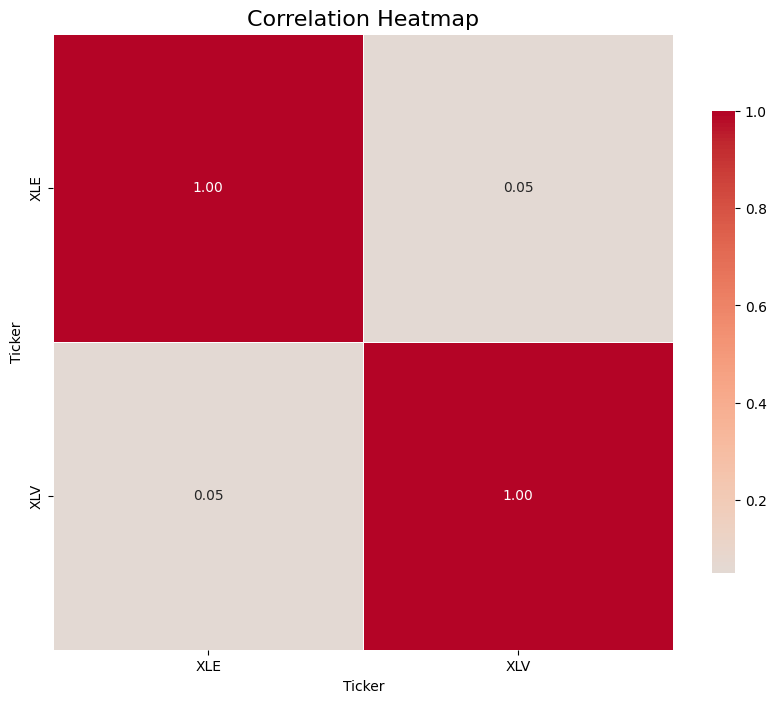

In [20]:

# Example usage
tickers = mrs_1m_df['ETF'].to_list()
ranked_picks = tickers


final_selection, corr_matrix = get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66)

# Step 2: Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Step 3: Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,         # Show correlation values
    fmt=".2f",          # Format to 2 decimal places
    cmap="coolwarm",    # Color map
    center=0,           # Center the colormap at 0
    linewidths=0.5,     # Lines between cells
    cbar_kws={"shrink": 0.75}  # Shrink color bar
)

# Step 4: Add title and show
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [21]:
final_selection

['XLE', 'XLV']

In [47]:
# Function to compute ATR (Average True Range)
def compute_atr(df, period=10):
  try:
    df['High-Low'] = df['High'] - df['Low']
    df['High-Close'] = abs(df['High'] - df['Close'].shift(1))
    df['Low-Close'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['High-Low', 'High-Close', 'Low-Close']].max(axis=1)
    return df['TR'].rolling(window=period).mean()
  except Exception as e:
      print("Something went wrong whilecomputing the ATR", e)


# Function to fetch daily data
def get_daily_data(ticker):
    df = yf.download(ticker, period="1y", interval="1d",auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first level
    df['20_day_SMA'] = df['Close'].rolling(window=20).mean()
    df['20_day_EMA'] = df['Close'].ewm(span=20, adjust=False).mean()
    df['50_day_avg_volume'] = df['Volume'].rolling(window=50).mean()
    df['8_day_EMA'] = df['Close'].ewm(span=8, adjust=False).mean()
    df['15_day_EMA'] = df['Close'].ewm(span=15, adjust=False).mean()
    df['21_day_EMA'] = df['Close'].ewm(span=21, adjust=False).mean()
    df['26_day_EMA'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['50_day_SMA'] = df['Close'].rolling(window=50).mean()
    df['100_day_SMA'] = df['Close'].rolling(window=100).mean()
    df['200_day_SMA'] = df['Close'].rolling(window=200).mean()
    slope_50sma, _, _, _, _ = linregress(range(5), df["50_day_SMA"].tail(5))
    df['SMA_Slope_50'] = slope_50sma
    # Compute MACD using ta
    df["MACD_Line"] = ta.trend.macd(df["Close"], window_slow=26, window_fast=12)
    df["Signal_Line"] = ta.trend.macd_signal(df["Close"], window_slow=26, window_fast=12, window_sign=9)
    df["MACD_Hist"] = ta.trend.macd_diff(df["Close"], window_slow=26, window_fast=12, window_sign=9)
    df["MACD_Hist_above_zero"] = df["MACD_Hist"] > 0
    df["MACD_Hist_below_zero"] = df["MACD_Hist"] < 0
    df['macd_above_signal'] = df['MACD_Line'] > df['Signal_Line']
    df['macd_below_signal'] = df['MACD_Line'] < df['Signal_Line']
    # Add results to original DataFrame
    df['ATR'] =  compute_atr(df, 10)
    return df


def get_monthly_data(ticker):
  try:
      df = yf.download(ticker, period="10y", interval="1mo",auto_adjust=True)
      df['10_month_SMA'] = df['Close'].rolling(window=10).mean()
      df['ATR'] =  compute_atr(df, 10)

      return df
  except Exception as e:
      print("There is an error getting monthly data", e)


def get_heikin_ashi_signal(ticker="AAPL", period="6mo", interval="1d"):
    # Fetch OHLC data
    df = yf.download(ticker, period=period, interval=interval, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first level

    # Compute Heikin Ashi candles
    ha_df = pd.DataFrame(index=df.index)
    ha_df['HA_Close'] = (df['Open'] + df['High'] + df['Low'] + df['Close']) / 4

    ha_open = []
    for i in range(len(df)):
        if i == 0:
             ha_open.append((df['Open'].iloc[i] + df['Close'].iloc[i]) / 2)
        else:
            ha_open.append((ha_open[i-1] + ha_df['HA_Close'].iloc[i-1]) / 2)
    ha_df['HA_Open'] = ha_open
    ha_df['HA_High'] = ha_df[['HA_Open', 'HA_Close']].assign(High=df['High']).max(axis=1)
    ha_df['HA_Low'] = ha_df[['HA_Open', 'HA_Close']].assign(Low=df['Low']).min(axis=1)

    # Combine with original
    df = df.join(ha_df)
    # Check for green candle with flat bottom
    last = df.iloc[-1]
    green_candle = last['HA_Close'] > last['HA_Open']
    flat_bottom = abs(last['HA_Open'] - last['HA_Low']) < 0.01  # tiny wick or flat bottom tolerance
    signal = green_candle and flat_bottom

    print(f"\n🔍 Checking {ticker} ({interval} timeframe)")
    print(f"HA_Open: {last['HA_Open']:.2f}, HA_Close: {last['HA_Close']:.2f}, HA_Low: {last['HA_Low']:.2f}")
    if signal:
        print("✅ Heikin Ashi candle is GREEN with a FLAT bottom — strong bullish signal!")
    elif green_candle:
        print("🟢 Candle is green but not flat-bottomed — still bullish, but less strong.")
    else:
        print("🔴 Not a bullish candle — no entry confirmation yet.")

    return signal, green_candle


def anchored_vwap_old(ticker, anchor_date):
    """
    Calculate Anchored VWAP starting from a given anchor_date.
    Works with both single-level and multi-level columns (e.g. yfinance output).
    """
    # --- Step 1: Flatten columns if multi-index ---
    df = yf.download(ticker, period="1y", interval="1d",auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first level

    # --- Step 2: Ensure required columns exist ---
    required_cols = ["High", "Low", "Close", "Volume"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    # --- Step 3: Subset from anchor_date ---
    df_anchor = df.loc[df.index >= pd.to_datetime(anchor_date)].copy()
    if df_anchor.empty:
        raise ValueError(f"No data found on/after {anchor_date}")

    # --- Step 4: Compute typical price ---
    df_anchor["typical_price"] = (df_anchor["High"] + df_anchor["Low"] + df_anchor["Close"]) / 3.0

    # --- Step 5: Cumulative PV and VWAP ---
    df_anchor["cum_pv"] = (df_anchor["typical_price"].astype(float) * df_anchor["Volume"].astype(float)).cumsum()
    df_anchor["cum_vol"] = df_anchor["Volume"].astype(float).cumsum()
    df_anchor["anchored_vwap"] = df_anchor["cum_pv"] / df_anchor["cum_vol"]

    return df_anchor[["anchored_vwap"]]

[*********************100%***********************]  12 of 12 completed


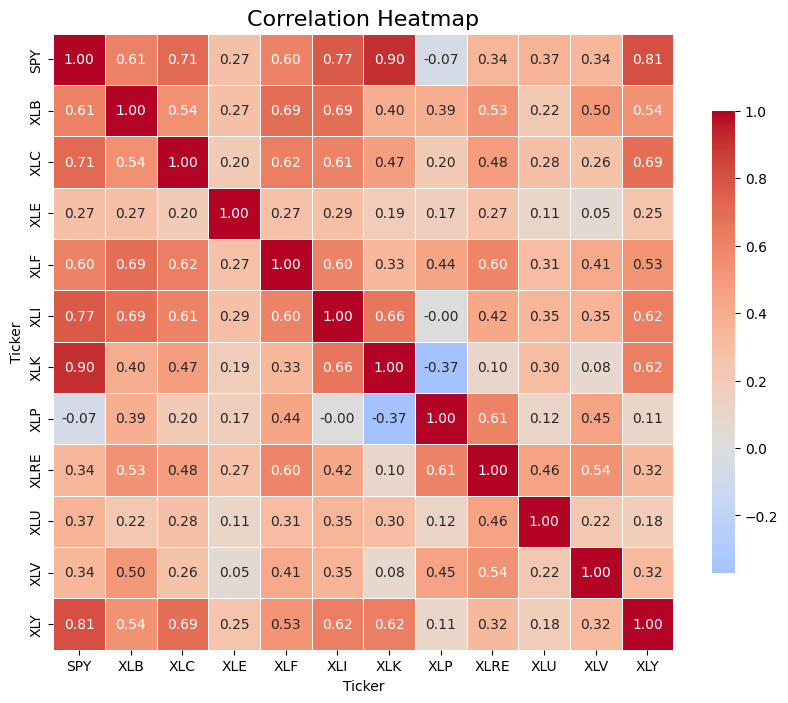

In [23]:

# Example usage
tickers = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB","XLC","SPY"]
ranked_picks = tickers


final_selection, corr_matrix = get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66)

# Step 2: Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Step 3: Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,         # Show correlation values
    fmt=".2f",          # Format to 2 decimal places
    cmap="coolwarm",    # Color map
    center=0,           # Center the colormap at 0
    linewidths=0.5,     # Lines between cells
    cbar_kws={"shrink": 0.75}  # Shrink color bar
)

# Step 4: Add title and show
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

# Short Term Sector Rotation Strategy

In [8]:
class STSectorRotationRanker:
    def __init__(self, price_data: pd.DataFrame, breadth_df: pd.DataFrame, sector_etfs: list, benchmark: str = 'SPY'):
        """
        price_data: DataFrame of adjusted closes with Date index (ascending) and columns for tickers (including benchmark).
        breadth_df: DataFrame of most recent market breadth data for tickers.
        sector_etfs: list of sector ETF tickers to rank (strings).
        benchmark: ticker string present in price_data used as market benchmark (default 'SPY').

        """
        self.price_data = price_data.copy().sort_index()
        self.sector_etfs = sector_etfs
        self.benchmark = benchmark
        self.breadth_df = breadth_df

        if benchmark not in self.price_data.columns:
            raise ValueError(f"Benchmark {benchmark} not found in price_data columns.")

    def _relative_series(self, ticker):
        """Return ratio series ticker / benchmark (RS series)."""
        return self.price_data[ticker] / self.price_data[self.benchmark]

    def compute_basic_rs(self, short_window=21, mid_window=63):
        """Compute RS1M and RS3M as relative % change vs benchmark over short/mid windows."""
        results = []
        for t in self.sector_etfs:
            if t not in self.price_data.columns:
                results.append({'ticker': t, 'RS1M': np.nan, 'RS3M': np.nan})
                continue
            rel = self._relative_series(t)
            #rs1m = (rel.iloc[-1] / rel.shift(short_window).iloc[-1] - 1) if len(rel) > short_window else np.nan
            #rs3m = (rel.iloc[-1] / rel.shift(mid_window).iloc[-1] - 1) if len(rel) > mid_window else np.nan
            rs1m = rel.pct_change(short_window).iloc[-1] if len(rel) > short_window else np.nan
            rs3m = rel.pct_change(mid_window).iloc[-1] if len(rel) > mid_window else np.nan
            results.append({'ticker': t, 'RS1M': rs1m, 'RS3M': rs3m})
        return pd.DataFrame(results).set_index('ticker')

    def compute_rs_slope(self, window=21):
        """Compute linear regression slope of RS series over `window` bars (last window)."""
        slopes = {}
        x = np.arange(window)
        for t in self.sector_etfs:
            if t not in self.price_data.columns:
                slopes[t] = np.nan
                continue
            rel = self._relative_series(t).dropna()
            if len(rel) < window:
                slopes[t] = np.nan
                continue
            y = rel.values[-window:]
            slope, intercept, r, p, se = linregress(x, y)
            slopes[t] = slope
        return pd.Series(slopes, name='RS_Slope')

    def compute_rolling_rs_acceleration(self, slope_window=21, accel_window=5):
        """
        Compute acceleration = change in rolling slope over accel_window steps.
        slope_window: how many bars to fit each rolling slope
        accel_window: how many slope-steps to look back for acceleration
        """
        acc = {}
        for t in self.sector_etfs:
            if t not in self.price_data.columns:
                acc[t] = np.nan
                continue
            rel = self._relative_series(t).dropna()
            if len(rel) < slope_window + accel_window:
                acc[t] = np.nan
                continue
            slopes = []
            for i in range(len(rel) - slope_window + 1):
                y = rel.values[i:i+slope_window]
                x = np.arange(slope_window)
                slope = linregress(x, y)[0]
                slopes.append(slope)
            slopes = np.array(slopes)
            acc_val = slopes[-1] - slopes[-1-accel_window] if len(slopes) > accel_window else np.nan
            acc[t] = acc_val
        return pd.Series(acc, name='RS_Acceleration')

    def merge_with_breadth(self):
      """
      Merge RS factors with breadth metrics
      breadth_df must have index=ticker symbols
      """
      rs = self.compute_basic_rs()
      slope = self.compute_rs_slope()
      accel = self.compute_rolling_rs_acceleration()
      df = rs.join(slope).join(accel)
      merged_df = df.join(self.breadth_df, how="left")

      # Fill missing values in each column of breadth_df with the column mean
      for col in breadth_df.columns:
          if col in merged_df.columns:
            #merged_df[col].fillna(merged_df[col].mean(), inplace=True)
            merged_df[col] = merged_df[col].fillna(merged_df[col].mean())

      return merged_df

    def compute_leader_score(self, rs1w=0.25, rs3w=0.35, slopew=0.3, accelw=0.1):
        """
        rs1w=0.4, rs3w=0.4, slopew=0.15, accelw=0.05
        Produce a DataFrame with RS1M, RS3M, RS_Slope, RS_Acceleration and Leader_Score.
        Leader_Score computed as weighted z-scores of metrics.
        """
        rs = self.compute_basic_rs()
        slope = self.compute_rs_slope()
        accel = self.compute_rolling_rs_acceleration()

        df1 = rs.join(slope).join(accel)
        df  = df1.join(self.breadth_df, how="left")
        # Fill missing values in each column of breadth_df with the column mean
        #for col in self.breadth_df.columns:
           #if col in df.columns:
               #df[col].fillna(df[col].mean(), inplace=True)
                #df[col] = df[col].fillna(df[col].mean())

        def zscore_col(s):
            # Use standard zscore; safe-guard against zero std
            return (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) != 0 else 1)

        z_rs1   = zscore_col(df['RS1M'])
        z_rs3   = zscore_col(df['RS3M'])
        z_slope = zscore_col(df['RS_Slope'])
        z_accel = zscore_col(df['RS_Acceleration'])

        score = rs1w*z_rs1 + rs3w*z_rs3 + slopew*z_slope + accelw*z_accel
        df['Leader_Score'] = score
        return df[['RS1M','RS3M','RS_Slope','RS_Acceleration','pct_above_50MA','pct_above_200MA','Leader_Score']]

    def final_ranking(self):
      """
       Return final ranking DataFrame. If breadth_df provided it will be joined.
       Adds a new column 'Rank' where highest Leader_Score gets rank 1.
      """
      # Compute the leader score
      merged = self.compute_leader_score()


      # Only select ETFs that have excellent marked breadth
      #merged = merged[(merged['pct_above_200MA'] >=50) & (merged['pct_above_50MA'] >=40)]
      # Sort by Leader_Score descending
      merged = merged.sort_values('Leader_Score', ascending=False)

      # Add a new ranking column
      merged['Rank'] = merged['Leader_Score'].rank(method='first', ascending=False).astype(int)


      return merged

In [9]:
if __name__ == "__main__":
  tickers = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB","XLC","SPY"]
  # Include market breadth data
  # Two snapshots so we can compute breadth ROC
  # Each value = dict of indicators
  data_dict = {
    "XLY": {"pct_above_50MA": 53, "pct_above_200MA": 63},
    "XLP": {"pct_above_50MA": 62, "pct_above_200MA": 35},
    "XLE": {"pct_above_50MA": 82, "pct_above_200MA": 73},
    "XLF": {"pct_above_50MA": 64, "pct_above_200MA": 66},
    "XLV": {"pct_above_50MA": 78, "pct_above_200MA": 70},
    "XLI": {"pct_above_50MA": 49, "pct_above_200MA": 61},
    "XLK": {"pct_above_50MA": 35, "pct_above_200MA": 59},
    "XLB": {"pct_above_50MA": 78, "pct_above_200MA": 44},
    "XLRE": {"pct_above_50MA": 39, "pct_above_200MA": 26},
    "XLC": {"pct_above_50MA": 33, "pct_above_200MA": 42},
    "XLU": {"pct_above_50MA": 48, "pct_above_200MA": 84}
    }
  breadth_df = pd.DataFrame.from_dict(data_dict, orient='index').reset_index()
  # Rename columns for clarity
  breadth_df.set_index('index', inplace=True)
  breadth_df.index.name = 'ticker'
  #breadth_df.index.name = 'ticker'
  data = yf.download( tickers, start="2000-01-01", end="2025-11-29",interval="1d",auto_adjust=True)['Close']
  #yf.download(tickers, period="1y", interval="1d",auto_adjust=True)['Close']
  price_data = data.ffill().dropna()
  # Instantiate and run ----------
  sectors = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB","XLC"]
  ranker = STSectorRotationRanker(price_data=price_data,breadth_df=breadth_df, sector_etfs=sectors, benchmark='SPY')
  #df_ranker = ranker.merge_with_breadth()
  #basic_rs = ranker.compute_leader_score()  #compute_basic_rs()
  df_ranking = ranker.final_ranking()

  #print(breadth_df)
def label_rs1m(rs1m):
    if rs1m >= 0.06:  return "BULLISH ≥6%"
    if rs1m >= 0.02:  return "Positive +2–6%"
    if rs1m >= -0.02: return "Neutral ±2%"
    if rs1m >= -0.05: return "BEARISH –2 to –5%"
    return "COLLAPSING <–5%"

def label_rs3m(rs3m):
    if rs3m >= 0.08:  return "LEADING ≥8%"
    if rs3m >= 0.00:  return "Recovering 0–8%"
    if rs3m >= -0.05: return "Lagging –5 to 0%"
    return "DEAD <–5%"

def label_rs_slope(slope):
    if slope >= 0.0045:      return "ROCKET / Parabolic"
    if slope >= 0.0030:      return "Very Strong Uptrend"
    if slope >= 0.0020:      return "Strong Uptrend"
    if slope >= 0.0012:      return "Moderate Uptrend"
    if slope >= 0.0006:      return "Mild Uptrend"
    if slope >= 0.0000:      return "Flat / Barely Positive"
    if slope >= -0.0010:     return "Flat / Losing Ground"
    return "Downtrend — Avoid"
def interpret_acceleration(acc):
      if acc >= 0.00030: return "ROCKET / Exploding"
      if acc >= 0.00020: return "Very strong acceleration"
      if acc >= 0.00012: return "Strong acceleration"
      if acc >= 0.00008: return "Positive acceleration"
      if acc >= 0.00000: return "Neutral/slightly positive"
      return "Deceleration / avoid"

def regime(row):
    if row['Slope_Label'].startswith('ROCKET') or row['Accel_Description'].startswith('ROCKET'):
        return "MONSTER INCOMING"
    if 'Strong' in row['Slope_Label'] or 'Very Strong' in row['Accel_Description']:
        return "Clear Leadership"
    if row['RS_Slope'] > 0.0015 and row['RS_Acceleration'] > 0.00015:
        return "Strong & Accelerating"
    if row['RS_Slope'] > 0:
        return "Improving"
    return "Wait / Avoid"



df_ranking['RS1M_Label'] = df_ranking['RS1M'].apply(label_rs1m)
df_ranking['RS3M_Label'] = df_ranking['RS3M'].apply(label_rs3m)
df_ranking['Slope_Label'] = df_ranking['RS_Slope'].apply(label_rs_slope)
df_ranking['Accel_Description'] = df_ranking['RS_Acceleration'].apply(interpret_acceleration)
df_ranking['Regime'] = df_ranking.apply(regime, axis=1)

df_ranking

[*********************100%***********************]  12 of 12 completed


,RS1M,RS3M,RS_Slope,RS_Acceleration,pct_above_50MA,pct_above_200MA,Leader_Score,Rank,RS1M_Label,RS3M_Label,Slope_Label,Accel_Description,Regime
ticker,,,,,,,,,,,,,
XLV,0.101353,0.084717,0.001286,0.000267,78,70,2.293979,1,BULLISH ≥6%,LEADING ≥8%,Moderate Uptrend,Very strong acceleration,Improving
XLU,0.011770,0.018538,0.000059,0.000032,48,84,0.230979,2,Neutral ±2%,Recovering 0–8%,Flat / Barely Positive,Neutral/slightly positive,Improving
XLP,0.042499,-0.068796,0.000285,0.000214,62,35,0.095292,3,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Very strong acceleration,Improving
XLC,-0.001931,-0.021510,0.000099,0.000259,33,42,0.034537,4,Neutral ±2%,Lagging –5 to 0%,Flat / Barely Positive,Very strong acceleration,Improving
XLE,0.033740,-0.050050,0.000129,-0.000092,82,73,-0.145121,5,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Deceleration / avoid,Improving
XLRE,0.031092,-0.065875,0.000068,0.000083,39,26,-0.197267,6,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Positive acceleration,Improving
XLB,0.029577,-0.083762,0.000142,0.000146,78,44,-0.242017,7,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Strong acceleration,Improving
XLF,0.029797,-0.067158,0.000045,0.000001,64,66,-0.286044,8,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Neutral/slightly positive,Improving
XLI,-0.003162,-0.044377,-0.000093,-0.000019,49,61,-0.454853,9,Neutral ±2%,Lagging –5 to 0%,Flat / Losing Ground,Deceleration / avoid,Wait / Avoid


In [10]:
def quick_verdict(row):
    bad_short = row['RS1M'] < -0.02                     # short-term momentum against us
    bad_long  = row['RS3M'] < -0.08                     # still in deep bear market
    monster   = (row['RS_Slope'] >= 0.0035) or (row['RS_Acceleration'] >= 0.00025)

    if bad_short and not monster:
        return "AVOID — short-term momentum too negative"
    if bad_long and row['Rank'] <= 2:
        return "CAUTION — still deeply underwater"
    if row['RS1M'] >= 0.04 and row['RS_Slope'] >= 0.002:
        return "SCREAMING BUY"
    return "Good"

df_ranking['Quick_Verdict'] = df_ranking.apply(quick_verdict, axis=1)

df_ranking


,RS1M,RS3M,RS_Slope,RS_Acceleration,pct_above_50MA,pct_above_200MA,Leader_Score,Rank,RS1M_Label,RS3M_Label,Slope_Label,Accel_Description,Regime,Quick_Verdict
ticker,,,,,,,,,,,,,,
XLV,0.101353,0.084717,0.001286,0.000267,78,70,2.293979,1,BULLISH ≥6%,LEADING ≥8%,Moderate Uptrend,Very strong acceleration,Improving,Good
XLU,0.011770,0.018538,0.000059,0.000032,48,84,0.230979,2,Neutral ±2%,Recovering 0–8%,Flat / Barely Positive,Neutral/slightly positive,Improving,Good
XLP,0.042499,-0.068796,0.000285,0.000214,62,35,0.095292,3,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Very strong acceleration,Improving,Good
XLC,-0.001931,-0.021510,0.000099,0.000259,33,42,0.034537,4,Neutral ±2%,Lagging –5 to 0%,Flat / Barely Positive,Very strong acceleration,Improving,Good
XLE,0.033740,-0.050050,0.000129,-0.000092,82,73,-0.145121,5,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Deceleration / avoid,Improving,Good
XLRE,0.031092,-0.065875,0.000068,0.000083,39,26,-0.197267,6,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Positive acceleration,Improving,Good
XLB,0.029577,-0.083762,0.000142,0.000146,78,44,-0.242017,7,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Strong acceleration,Improving,Good
XLF,0.029797,-0.067158,0.000045,0.000001,64,66,-0.286044,8,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Neutral/slightly positive,Improving,Good
XLI,-0.003162,-0.044377,-0.000093,-0.000019,49,61,-0.454853,9,Neutral ±2%,Lagging –5 to 0%,Flat / Losing Ground,Deceleration / avoid,Wait / Avoid,Good


# Sector Rotation Engine

In [17]:
class SectorRotationRanker:
    def __init__(self, price_data: pd.DataFrame, sector_etfs: list, benchmark: str = 'SPY'):
        """
        price_data: DataFrame of adjusted closes with Date index (ascending) and columns for tickers (including benchmark).
        sector_etfs: list of sector ETF tickers to rank (strings).
        benchmark: ticker string present in price_data used as market benchmark (default 'SPY').

        """
        self.price_data = price_data.copy().sort_index()
        self.sector_etfs = sector_etfs
        self.benchmark = benchmark

        if benchmark not in self.price_data.columns:
            raise ValueError(f"Benchmark {benchmark} not found in price_data columns.")

    def _relative_series(self, ticker):
        """Return ratio series ticker / benchmark (RS series)."""
        return self.price_data[ticker] / self.price_data[self.benchmark]

    def compute_basic_rs(self, short_window=126, mid_window=252):
        """Compute RS6M and RS12M as relative % change vs benchmark over short/mid windows."""
        results = []
        for t in self.sector_etfs:
            if t not in self.price_data.columns:
                results.append({'ticker': t, 'RS6M': np.nan, 'RS12M': np.nan})
                continue
            rel = self._relative_series(t)
            rs6m = rel.pct_change(short_window).iloc[-1] if len(rel) > short_window else np.nan
            rs12m = rel.pct_change(mid_window).iloc[-1] if len(rel) > mid_window else np.nan
            results.append({'ticker': t, 'RS6M': rs6m, 'RS12M': rs12m})
        return pd.DataFrame(results).set_index('ticker')

    def compute_leader_score(self, rs6w=0.7, rs12w=0.3):
        """
        rs6w=0.4, rs12w=0.4
        Produce a DataFrame with RS1M, RS3M,and Leader_Score.
        Leader_Score computed as weighted z-scores of metrics.
        """
        rs = self.compute_basic_rs()
        df = rs.copy()

        def zscore_col(s):
            # Use standard zscore; safe-guard against zero std
            return (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) != 0 else 1)

        z_rs6   = zscore_col(df['RS6M'])
        z_rs12   = zscore_col(df['RS12M'])

        score = rs6w*z_rs6 + rs12w*z_rs12
        df['Score'] = score
        return df[['RS6M','RS12M','Score']]

    def final_ranking(self):
      """
       Return final ranking DataFrame. If breadth_df provided it will be joined.
       Adds a new column 'Rank' where highest Leader_Score gets rank 1.
      """
      # Compute the leader score
      merged = self.compute_leader_score()


      # Only select ETFs that have excellent marked breadth
      # Sort by Leader_Score descending
      merged = merged.sort_values('Score', ascending=False)

      # Add a new ranking column
      merged['Rank'] = merged['Score'].rank(method='first', ascending=False).astype(int)


      return merged


In [18]:
if __name__ == "__main__":
  tickers = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB","XLC","SPY"]
  # Include market breadth data
  # Two snapshots so we can compute breadth ROC
  # Each value = dict of indicators
  data = yf.download( tickers, start="2022-01-01", end="2025-11-29",interval="1d",auto_adjust=True)['Close']
  #price_data = data.ffill().dropna()
  price_data = data
  # Instantiate and run ----------
  sectors = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB","XLC"]
  ranker = SectorRotationRanker(price_data=price_data, sector_etfs=sectors, benchmark='SPY')
  df = ranker.final_ranking()
  df.reset_index(inplace=True)

df


[*********************100%***********************]  12 of 12 completed


,ticker,RS6M,RS12M,Score,Rank
0,XLK,0.066066,0.065218,1.849105,1
1,XLV,0.028772,-0.046565,1.012028,2
2,XLC,-0.018377,0.035422,0.821372,3
3,XLU,-0.038276,-0.012361,0.420810,4
4,XLY,-0.047889,-0.064959,0.112636,5
5,XLE,-0.032725,-0.153275,-0.066734,6
6,XLI,-0.070570,-0.060844,-0.116323,7
7,XLF,-0.096548,-0.084476,-0.488700,8
8,XLB,-0.103319,-0.171352,-0.899365,9
9,XLRE,-0.129361,-0.166735,-1.162680,10


In [19]:
def quick_verdict(row):
    """
    One-line verdict when your ranking is based on 70/30 RELATIVE STRENGTH vs SPY.
    Row must contain: 'RS_6M', 'RS_12M', 'Score', 'Rank'
    """
    rs6   = row['RS6M']      # e.g. +0.184 = +18.4% outperformance vs SPY in 6 months
    rs12  = row['RS12M']
    score = row['Score']
    rank  = row['Rank']

    # ── TOP-2 → ALWAYS obey the model ─────────────────────────────────
    if rank == 1:
        if rs6 >= 0.20:   return "MONSTER #1 – strongest leader in years"
        if rs6 >= 0.12:   return "STRONG #1 – ride it hard"
        return "Weak #1 but still the leader – hold"

    if rank == 2:
        if rs6 >= 0.15:   return "VERY STRONG #2 – excellent companion"
        if rs6 >= 0.08:   return "SOLID #2 – normal winner"
        return "Marginal #2 – still hold mechanically"

    # ── Ranks 3–5 → only interesting if extremely close ───────────────
    if 3 <= rank <= 5:
        top2_score = df[df['Rank'].isin([1,2])]['Score'].min()
        if score >= top2_score * 0.96:   # within 4% of the weaker Top-2
            return "Almost made it – watch for next month"
        else:
            return "Mid-pack – ignore"

    # ── Bottom half → only flag disasters or hidden gems ───────────────
    if rs6 <= -0.20:
        return "CRASHING vs SPY – toxic"
    if rs12 <= -0.30:
        return "DEEP BEAR phase – dead for years"
    if rs6 >= 0.20 and rs12 >= 0.20:
        return "Strong but not ranked yet – model waiting for confirmation"

    return "Neutral – ignore"

In [14]:

df['Quick_Verdict'] = df.apply(quick_verdict, axis=1)

# Show only what matters
df.sort_values('Rank')[['ticker','RS6M','RS12M','Score','Rank','Quick_Verdict']]

,ticker,RS6M,RS12M,Score,Rank,Quick_Verdict
0,XLK,0.066066,0.065218,1.849105,1,Weak #1 but still the leader – hold
1,XLV,0.028772,-0.046565,1.012028,2,Marginal #2 – still hold mechanically
2,XLC,-0.018377,0.035422,0.821372,3,Mid-pack – ignore
3,XLU,-0.038276,-0.012361,0.420810,4,Mid-pack – ignore
4,XLY,-0.047889,-0.064959,0.112636,5,Mid-pack – ignore
5,XLE,-0.032725,-0.153275,-0.066734,6,Neutral – ignore
6,XLI,-0.070570,-0.060844,-0.116323,7,Neutral – ignore
7,XLF,-0.096548,-0.084476,-0.488700,8,Neutral – ignore
8,XLB,-0.103319,-0.171352,-0.899365,9,Neutral – ignore
9,XLRE,-0.129361,-0.166735,-1.162680,10,Neutral – ignore


In [82]:
# sector_rotation_backtest.py
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime

# -------------------------
# Settings
# -------------------------
start_date = "2000-01-01"
end_date   = "2024-12-31"

# Sector ETFs — include common SPDR sector ETFs (including Real Estate & Comm Services)
sector_tickers = [
    "XLB",  # Materials
    "XLE",  # Energy
    "XLF",  # Financials
    "XLI",  # Industrials
    "XLK",  # Technology
    "XLP",  # Consumer Staples
    "XLU",  # Utilities
    "XLV",  # Health Care
    "XLY",  # Consumer Discretionary
    "XLC",  # Communication Services
    "XLRE"  # Real Estate
]

benchmark = "SPY"  # benchmark ticker

top_n = 2  # pick top 2 sectors monthly
skip_last_month = False  # set True to exclude the most recent month when computing momentum (optional)
rebalance_on = "first"  # "first" trading day after month end

# -------------------------
# Helper functions
# -------------------------
def download_adj_close(tickers, start, end):
    data = yf.download(tickers, start=start, end=end, progress=False, auto_adjust=True)["Close"]
    # if single ticker returns Series, convert
    if isinstance(data, pd.Series):
        data = data.to_frame(name=tickers[0])
    return data

def calc_annualized_return(series):
    days = (series.index[-1] - series.index[0]).days
    total_return = series.iloc[-1] / series.iloc[0] - 1
    return (1 + total_return) ** (365.0 / days) - 1

def max_drawdown(nav):
    peak = nav.cummax()
    dd = (nav - peak) / peak
    return dd.min()

# -------------------------
# Download data
# -------------------------
tickers = sector_tickers + [benchmark]
prices = download_adj_close(tickers, start_date, end_date).dropna(how='all')  # daily adj close

# Align columns (some ETFs have missing early history)
prices = prices.sort_index()

# -------------------------
# Monthly scoring data
# -------------------------
# Use month-end close for scoring
monthly = prices.resample('ME').last()
monthly.index = monthly.index.normalize()

# Optionally skip the most recent month: shift reference index forward by 1 month
shift_months = 1 if skip_last_month else 0

# Function to compute n-month pct change using month-end series
def pct_change_months(series, months):
    return series.pct_change(periods=months).rename(f"pct_{months}m")

# Compute RS6 and RS12 for each ETF (in percent)
rs6  = monthly[sector_tickers].pct_change(periods=6).multiply(100)
rs12 = monthly[sector_tickers].pct_change(periods=12).multiply(100)

# If skipping last month, shift the score reference back one row (so current month's selection uses data up to previous month)
if shift_months:
    rs6  = rs6.shift(1)
    rs12 = rs12.shift(1)

# Build score DataFrame aligned to month-end
score = 0.7 * rs6 + 0.3 * rs12

# -------------------------
# Build monthly selections
# -------------------------
# For each month (use index of 'score'), choose top_n tickers that have non-null scores
selections = {}
for dt in score.index:
    row = score.loc[dt].dropna()
    if len(row) >= 1:
        top = row.sort_values(ascending=False).index.tolist()[:top_n]
    else:
        top = []
    selections[dt] = top

# -------------------------
# Simulate monthly rebalancing using daily prices
# Rebalance on the first trading day of the next month after month-end
# -------------------------
daily = prices.copy().dropna(how='all')  # daily adj closes
daily = daily.sort_index()

# Generate a mapping: for each month-end date dt, find the next trading day index to apply the allocation
rebalance_dates = {}
all_month_ends = score.index

# Find first trading day AFTER each month-end in daily index
for dt in all_month_ends:
    future_days = daily.index[daily.index > dt]
    if len(future_days) == 0:
        reb_date = None
    else:
        reb_date = future_days[0]
    rebalance_dates[dt] = reb_date

# Build a daily allocation DataFrame with weights for each ticker on each calendar day
alloc = pd.DataFrame(0.0, index=daily.index, columns=sector_tickers)

# Walk through months and set allocations starting from rebalance date until next rebalance
sorted_months = [m for m in all_month_ends if rebalance_dates[m] is not None]
for i, m in enumerate(sorted_months):
    start_day = rebalance_dates[m]
    end_day = None
    if i + 1 < len(sorted_months):
        next_m = sorted_months[i+1]
        end_day = rebalance_dates[next_m]  # allocation valid until next rebalance date (exclusive)
    else:
        end_day = daily.index[-1] + pd.Timedelta(days=1)
    # get selection for this month
    chosen = selections.get(m, [])
    if len(chosen) == 0:
        continue
    w = 1.0 / len(chosen)
    mask = (daily.index >= start_day) & (daily.index < end_day)
    for t in chosen:
        # check if price exists for t on start_day; if not, weight remains 0 (skip)
        # assign weight w for the mask days
        alloc.loc[mask, t] = w

# -------------------------
# Compute daily portfolio returns
# -------------------------
# daily pct changes for sectors
daily_ret = daily[sector_tickers].pct_change().fillna(0)

# portfolio daily returns = sum(weights_t * ret_t) across tickers for each day
# Ensure alloc and daily_ret align
port_daily_ret = (alloc.shift(1).fillna(0) * daily_ret).sum(axis=1)  # shift weights so rebalance uses next day's returns
# The shifting ensures allocations set on rebalance_date are applied to returns from that day onward

# compute portfolio NAV
nav = (1 + port_daily_ret).cumprod()

# compute benchmark nav (SPY buy and hold)
spy_daily_ret = daily[benchmark].pct_change().fillna(0)
spy_nav = (1 + spy_daily_ret).cumprod()

# -------------------------
# Metrics
# -------------------------
def compute_metrics(nav_series):
    total_return = nav_series.iloc[-1] / nav_series.iloc[0] - 1
    cagr = calc_annualized_return(nav_series)
    ann_vol = nav_series.pct_change().std() * np.sqrt(252)
    mdd = max_drawdown(nav_series)
    return {
        "total_return": total_return,
        "CAGR": cagr,
        "annual_vol": ann_vol,
        "max_drawdown": mdd
    }

metrics_port = compute_metrics(nav)
metrics_spy  = compute_metrics(spy_nav)

# -------------------------
# Output results
# -------------------------
print("Backtest period:", daily.index[0].date(), "to", daily.index[-1].date())
print("\nStrategy (top {} sectors) Metrics:".format(top_n))
for k,v in metrics_port.items():
    if k == "max_drawdown":
        print(f"  {k}: {v:.2%}")
    else:
        print(f"  {k}: {v:.2%}")

print("\nBenchmark (SPY buy & hold) Metrics:")
for k,v in metrics_spy.items():
    if k == "max_drawdown":
        print(f"  {k}: {v:.2%}")
    else:
        print(f"  {k}: {v:.2%}")

# Save CSVs for inspection
nav_df = pd.DataFrame({"strategy_nav": nav, "spy_nav": spy_nav}).dropna()
nav_df.to_csv("navs.csv")
alloc.to_csv("monthly_allocations_daily.csv")
score.to_csv("monthly_scores.csv")

print("\nSaved: navs.csv, monthly_allocations_daily.csv, monthly_scores.csv")
print("Notes: Some ETFs (e.g., XLC, XLRE) may not have data back to 2000 — the code handles missing data by skipping null scores.")


Backtest period: 2000-01-03 to 2024-12-30

Strategy (top 2 sectors) Metrics:
  total_return: 596.76%
  CAGR: 8.07%
  annual_vol: 19.38%
  max_drawdown: -43.22%

Benchmark (SPY buy & hold) Metrics:
  total_return: 534.59%
  CAGR: 7.67%
  annual_vol: 19.39%
  max_drawdown: -55.19%

Saved: navs.csv, monthly_allocations_daily.csv, monthly_scores.csv
Notes: Some ETFs (e.g., XLC, XLRE) may not have data back to 2000 — the code handles missing data by skipping null scores.


=== YOUR SECTOR ROTATION (Top-2, 70/30 Relative Strength) ===
CAGR         : 9.14%
Max Drawdown : -9.84%
Final Value  : $14,288

=== SPY Buy & Hold ===
CAGR         : 13.59%
Max Drawdown : -23.93%


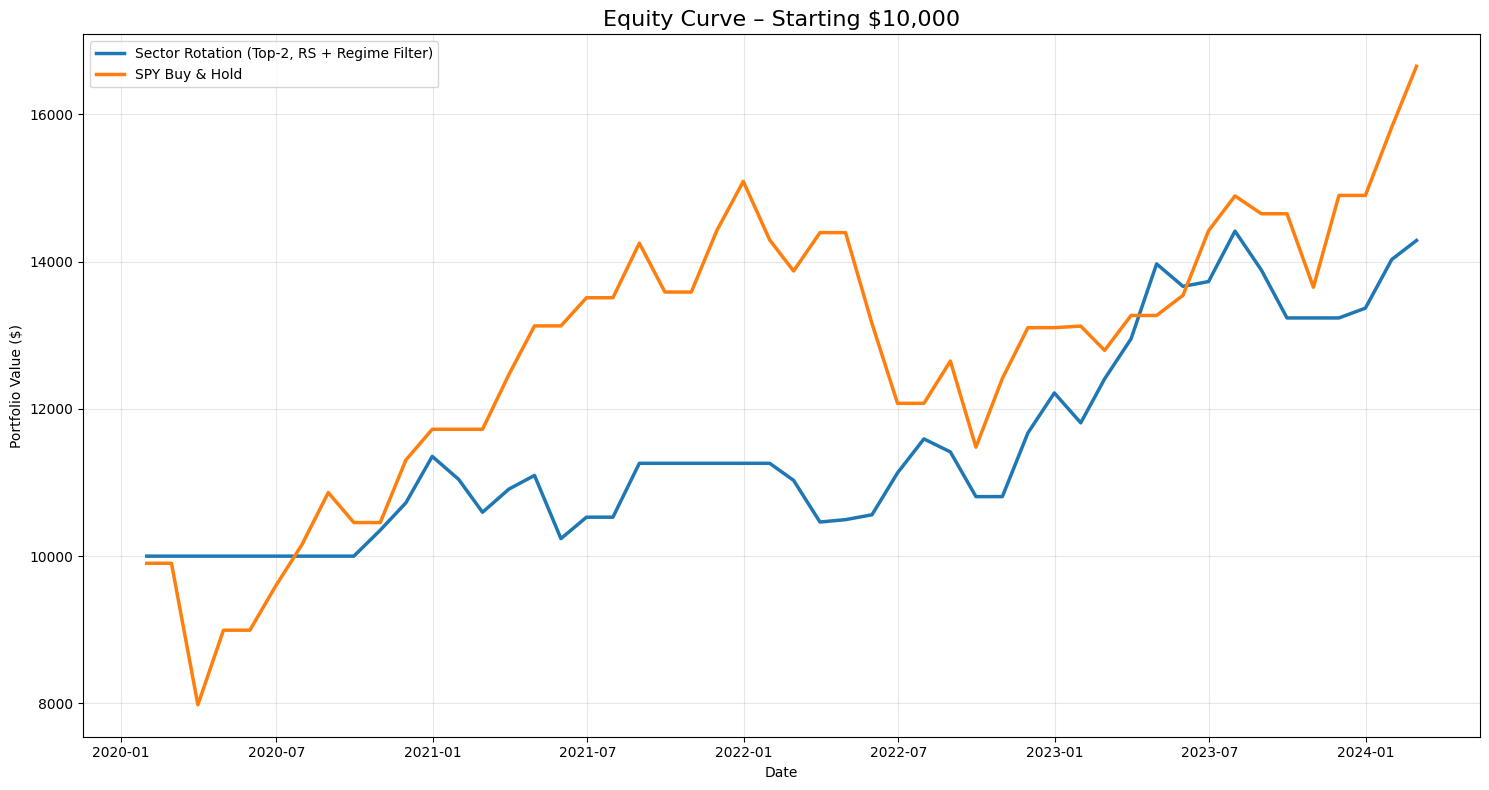


=== RECOMMENDED HOLD FOR DECEMBER 2025 (as of 2025-12-05) ===
Top Picks (equal-weight):
  1. XLK: Score 0.0756
  2. XLC: Score 0.0002


In [4]:

# ============================
# SETTINGS – YOUR EXACT LIVE RULES
# ============================
sectors = ["XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV", "XLY", "XLC", "XLRE"]
benchmark = "SPY"
start_date = "2020-01-01"
top_n = 2                          # Top 2 equal-weight
use_relative_strength = True       # Relative strength vs SPY (your preference)
regime_filter = True               # 200-day SMA defense (recommended)

# ============================
# DOWNLOAD & CLEAN DATA
# ============================
tickers = sectors + [benchmark]
prices = yf.download(tickers, start=start_date, progress=False, auto_adjust=True)["Close"]
prices = prices.dropna(how='all').ffill()  # Forward-fill missing prices (handles new ETFs)

# ============================
# MOMENTUM: 70/30 Relative Strength
# ============================
if use_relative_strength:
    # Sector / SPY ratio, then % change
    rel_prices = prices[sectors].div(prices[benchmark], axis=0)
    mom_6m = rel_prices.pct_change(126)   # ~6 months RS
    mom_12m = rel_prices.pct_change(252)  # ~12 months RS
else:
    mom_6m = prices[sectors].pct_change(126)
    mom_12m = prices[sectors].pct_change(252)

score = 0.70 * mom_6m + 0.30 * mom_12m

# ============================
# REGIME FILTER: SPY > 200-day SMA?
# ============================
if regime_filter:
    sma200 = prices[benchmark].rolling(200).mean()
    in_market = prices[benchmark] > sma200
else:
    in_market = pd.Series(True, index=prices.index)

# ============================
# MONTHLY REBALANCE SIMULATION
# ============================
monthly_dates = prices.resample("ME").last().index  # Month-end dates

portfolio_value = 10000.0
holdings = {}  # {ticker: shares}
equity_values = []  # Track monthly portfolio values

for i, date in enumerate(monthly_dates):
    if date not in prices.index:
        continue

    # Step 1: Calculate CURRENT portfolio value (grow holdings to today)
    current_value = 0.0
    for tic, shares in holdings.items():
        if tic in prices.columns and pd.notna(prices.loc[date, tic]):
            current_value += shares * prices.loc[date, tic]
    if current_value <= 0:
        current_value = portfolio_value  # Fallback for early months/cash

    # Step 2: Regime check & select Top-N
    if not in_market.loc[date]:
        # Bear market → 100% cash (or swap to SHY/TLT ETF here if you want yield)
        selected_tickers = []
    else:
        # Bull market → Top-N by score (handle NaNs/missing data)
        available_scores = score.loc[date].dropna()
        if len(available_scores) >= top_n:
            selected_tickers = available_scores.nlargest(top_n).index.tolist()
        elif len(available_scores) > 0:
            selected_tickers = available_scores.nlargest(len(available_scores)).index.tolist()
        else:
            selected_tickers = []

    # Step 3: Rebalance (sell old, buy new equal-weight)
    new_holdings = {}
    if len(selected_tickers) > 0:
        weight_per = 1.0 / len(selected_tickers)
        for tic in selected_tickers:
            if tic in prices.columns and pd.notna(prices.loc[date, tic]):
                shares = (current_value * weight_per) / prices.loc[date, tic]
                new_holdings[tic] = shares
    # Else: stay in cash, holdings empty

    holdings = new_holdings
    portfolio_value = current_value  # Updated for next iteration
    equity_values.append(current_value)

# ============================
# EQUITY CURVES
# ============================
equity_curve = pd.Series(equity_values, index=monthly_dates[:len(equity_values)])
equity_curve = equity_curve.ffill()  # Fill any gaps for smooth plotting

# SPY benchmark (buy & hold)
spy_start = prices[benchmark].dropna().iloc[0]
spy_curve = (prices[benchmark] / spy_start * 10000).reindex(equity_curve.index).ffill()

# ============================
# METRICS (Robust to NaNs/Short Series)
# ============================
def calc_cagr(series):
    if len(series.dropna()) < 2:
        return np.nan
    clean = series.dropna()
    years = (clean.index[-1] - clean.index[0]).days / 365.25
    return (clean.iloc[-1] / clean.iloc[0]) ** (1 / years) - 1

def calc_max_dd(series):
    if len(series.dropna()) < 2:
        return np.nan
    clean = series.dropna()
    peak = clean.cummax()
    dd = (clean - peak) / peak
    return dd.min()

# ============================
# OUTPUT RESULTS
# ============================
print("=== YOUR SECTOR ROTATION (Top-2, 70/30 Relative Strength) ===")
print(f"CAGR         : {calc_cagr(equity_curve):.2%}")
print(f"Max Drawdown : {calc_max_dd(equity_curve):.2%}")
print(f"Final Value  : ${equity_curve.iloc[-1]:,.0f}")

print("\n=== SPY Buy & Hold ===")
print(f"CAGR         : {calc_cagr(spy_curve):.2%}")
print(f"Max Drawdown : {calc_max_dd(spy_curve):.2%}")

# ============================
# PLOT EQUITY CURVES
# ============================
plt.figure(figsize=(15, 8))
plt.plot(equity_curve, label=f"Sector Rotation (Top-{top_n}, RS + Regime Filter)", linewidth=2.5)
plt.plot(spy_curve, label="SPY Buy & Hold", linewidth=2.5)
plt.title("Equity Curve – Starting $10,000", fontsize=16)
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================
# CURRENT PICKS (For December 2025 Hold)
# ============================
latest_date = prices.index[-1]
latest_scores = score.loc[latest_date].dropna()
top_picks = latest_scores.nlargest(top_n)

print(f"\n=== RECOMMENDED HOLD FOR DECEMBER 2025 (as of {latest_date.date()}) ===")
print("Top Picks (equal-weight):")
for i, (tic, sc) in enumerate(top_picks.items(), 1):
    print(f"  {i}. {tic}: Score {sc:.4f}")